In [4]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from IPython.display import Audio

plt.style.use("ggplot")

In [5]:
DATASET_PATH = "dataset/mini_speech_commands"

In [7]:
classes = sorted([
    folder
    for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print(classes)
print("Number of Classes:", len(classes))

['down', 'go', 'left', 'no', 'right', 'stop', 'up', 'yes']
Number of Classes: 8


In [8]:
sample_counts = {}

for cls in classes:
    folder_path = os.path.join(DATASET_PATH, cls)

    wav_files = [
        file for file in os.listdir(folder_path)
        if file.endswith(".wav")
    ]

    sample_counts[cls] = len(wav_files)

sample_counts

{'down': 1000,
 'go': 1000,
 'left': 1000,
 'no': 1000,
 'right': 1000,
 'stop': 1000,
 'up': 1000,
 'yes': 1000}

In [9]:
df = pd.DataFrame({
    "Class": sample_counts.keys(),
    "Samples": sample_counts.values()
})

df

,Class,Samples
0,down,1000
1,go,1000
2,left,1000
3,no,1000
4,right,1000
5,stop,1000
6,up,1000
7,yes,1000


In [10]:
total_samples = df["Samples"].sum()

print("Total Samples:", total_samples)

Total Samples: 8000


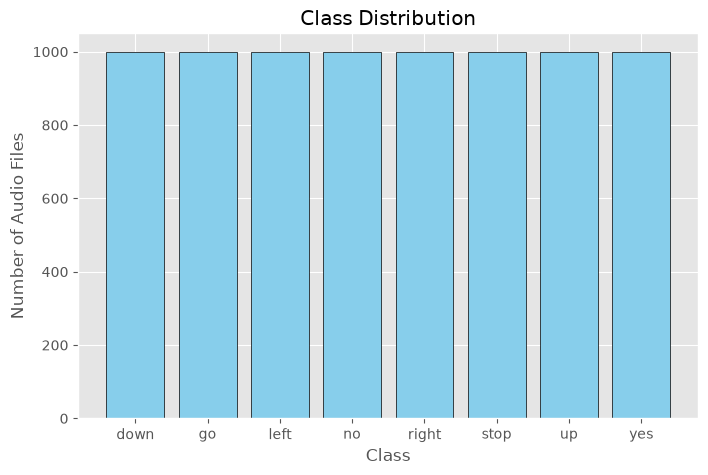

In [11]:
plt.figure(figsize=(8,5))

plt.bar(df["Class"], df["Samples"], color="skyblue", edgecolor="black")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Audio Files")

plt.show()

In [12]:
sample_file = os.path.join(
    DATASET_PATH,
    "yes",
    os.listdir(os.path.join(DATASET_PATH, "yes"))[0]
)

print(sample_file)

dataset/mini_speech_commands\yes\004ae714_nohash_0.wav


In [13]:
audio, sr = librosa.load(sample_file, sr=None)

print("Sample Rate:", sr)
print("Number of Audio Samples:", len(audio))

Sample Rate: 16000
Number of Audio Samples: 16000


In [14]:
duration = len(audio) / sr

print("Duration:", duration, "seconds")

Duration: 1.0 seconds


In [15]:
total_duration = 0

for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)

    for file in os.listdir(folder):

        if file.endswith(".wav"):

            path = os.path.join(folder, file)

            y, sr = librosa.load(path, sr=None)

            total_duration += len(y) / sr

print(f"Total Duration: {total_duration:.2f} seconds")
print(f"Total Duration: {total_duration/60:.2f} minutes")

Total Duration: 7869.62 seconds
Total Duration: 131.16 minutes


In [16]:
    Audio(sample_file)

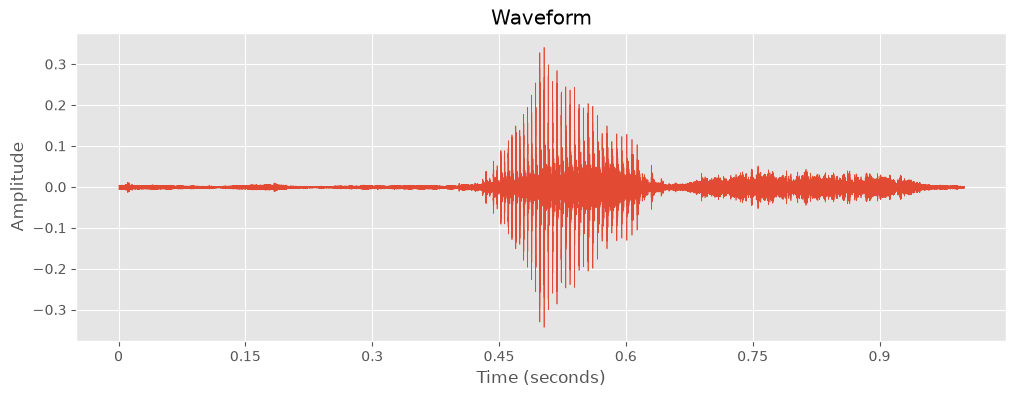

In [17]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(audio, sr=sr)

plt.title("Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

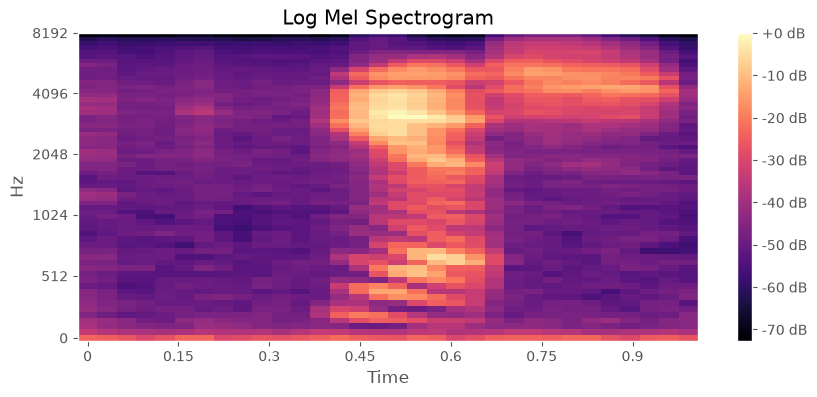

In [18]:
mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=64
)

mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Log Mel Spectrogram")

plt.show()

In [19]:
for cls in classes:

    folder = os.path.join(DATASET_PATH, cls)

    sample = os.listdir(folder)[0]

    print(f"\nClass: {cls}")

    display(Audio(os.path.join(folder, sample)))


Class: down



Class: go



Class: left



Class: no



Class: right



Class: stop



Class: up



Class: yes


In [27]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

class AudioPreprocessor:
    def __init__(self, sr=16000, n_mels=64, n_fft=1024,
                 hop_length=512, target_duration=4.0):

        self.sr = sr
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.target_samples = int(sr * target_duration)

    # --------------------------------------------------
    # Load audio, convert to mono and resample
    # --------------------------------------------------
    def load_and_resample(self, path):

        y, sr = librosa.load(
            path,
            sr=self.sr,
            mono=True
        )

        return y

    # --------------------------------------------------
    # Pad short audio or truncate long audio
    # --------------------------------------------------
    def pad_or_truncate(self, y):

        if len(y) < self.target_samples:

            padding = self.target_samples - len(y)

            y = np.pad(
                y,
                (0, padding),
                mode="constant"
            )

        else:

            y = y[:self.target_samples]

        return y

    # --------------------------------------------------
    # Convert audio into Log Mel Spectrogram
    # --------------------------------------------------
    def extract_mel_spectrogram(self, y):

        mel = librosa.feature.melspectrogram(
            y=y,
            sr=self.sr,
            n_mels=self.n_mels,
            n_fft=self.n_fft,
            hop_length=self.hop_length
        )

        log_mel = librosa.power_to_db(
            mel,
            ref=np.max
        )

        # Add channel dimension
        log_mel = np.expand_dims(log_mel, axis=0)

        return log_mel

    # --------------------------------------------------
    # Complete preprocessing pipeline
    # --------------------------------------------------
    def process(self, path):

        y = self.load_and_resample(path)

        y = self.pad_or_truncate(y)

        mel = self.extract_mel_spectrogram(y)

        return mel

In [28]:
preprocessor = AudioPreprocessor()

spectrogram = preprocessor.process(sample_file)

print("Spectrogram Shape:", spectrogram.shape)

Spectrogram Shape: (1, 64, 126)


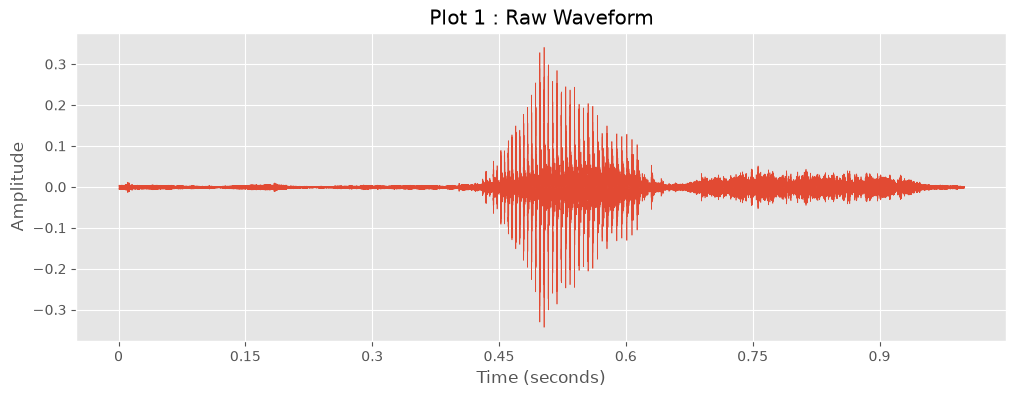

In [29]:
raw_audio, original_sr = librosa.load(sample_file, sr=None)

plt.figure(figsize=(12,4))

librosa.display.waveshow(
    raw_audio,
    sr=original_sr
)

plt.title("Plot 1 : Raw Waveform")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

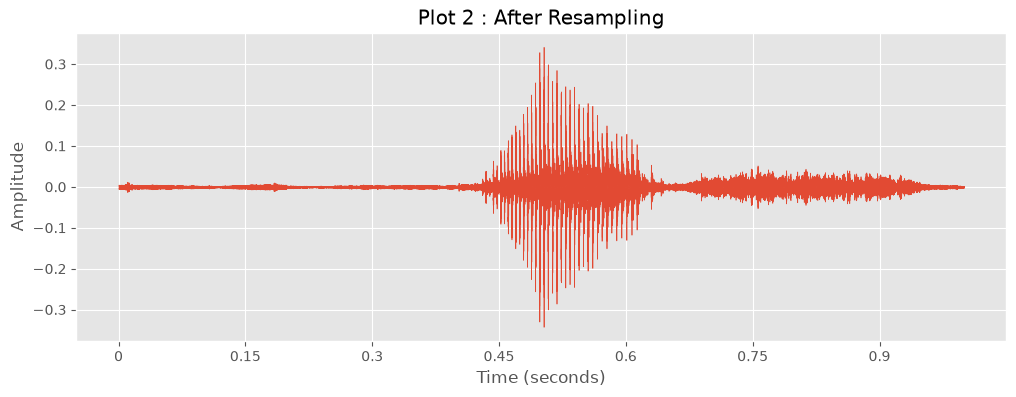

In [30]:
resampled_audio = preprocessor.load_and_resample(sample_file)

plt.figure(figsize=(12,4))

librosa.display.waveshow(
    resampled_audio,
    sr=preprocessor.sr
)

plt.title("Plot 2 : After Resampling")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

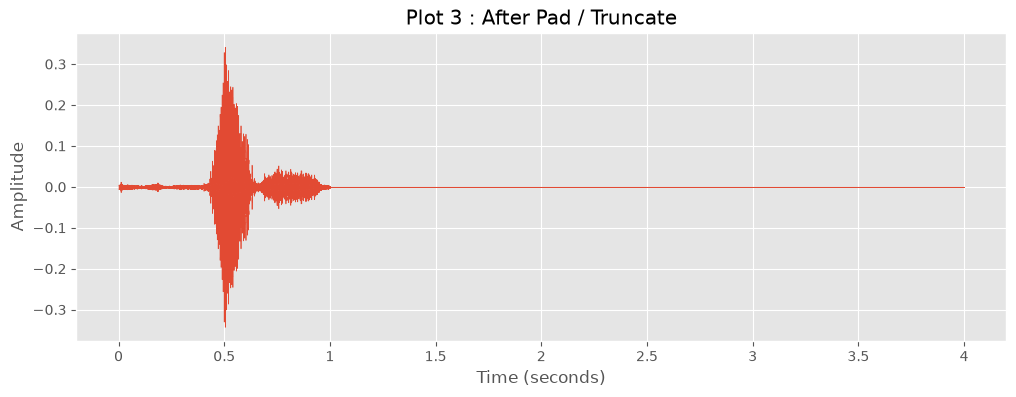

Length after preprocessing: 64000


In [31]:
processed_audio = preprocessor.pad_or_truncate(resampled_audio)

plt.figure(figsize=(12,4))

librosa.display.waveshow(
    processed_audio,
    sr=preprocessor.sr
)

plt.title("Plot 3 : After Pad / Truncate")

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

print("Length after preprocessing:", len(processed_audio))

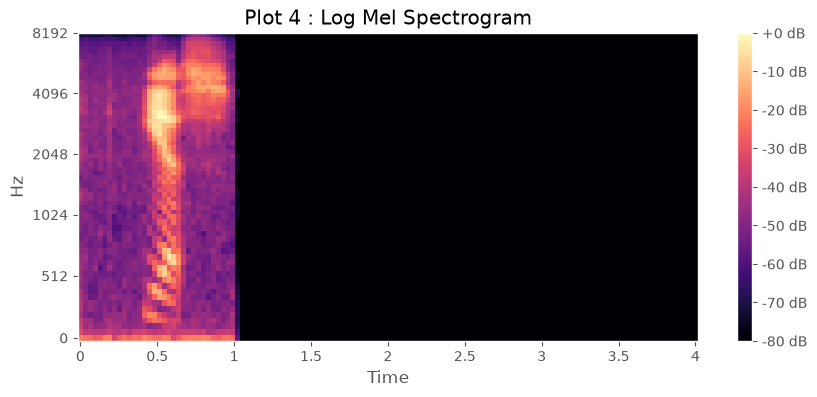

In [32]:
mel = preprocessor.extract_mel_spectrogram(processed_audio)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel[0],
    sr=preprocessor.sr,
    hop_length=preprocessor.hop_length,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")

plt.title("Plot 4 : Log Mel Spectrogram")

plt.show()

In [33]:
print("Original Audio Length :", len(raw_audio))
print("Resampled Length      :", len(resampled_audio))
print("Processed Length      :", len(processed_audio))
print("Mel Shape             :", mel.shape)

Original Audio Length : 16000
Resampled Length      : 16000
Processed Length      : 64000
Mel Shape             : (1, 64, 126)


Step-3

In [34]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [35]:
label_map = {}

for i, cls in enumerate(classes):
    label_map[cls] = i

print(label_map)

{'down': 0, 'go': 1, 'left': 2, 'no': 3, 'right': 4, 'stop': 5, 'up': 6, 'yes': 7}


In [36]:
file_list = []
labels = []

for cls in classes:

    folder = os.path.join(DATASET_PATH, cls)

    for file in os.listdir(folder):

        if file.endswith(".wav"):

            file_list.append(
                os.path.join(folder, file)
            )

            labels.append(
                label_map[cls]
            )

print("Total Audio Files:", len(file_list))
print("Total Labels:", len(labels))

Total Audio Files: 8000
Total Labels: 8000


In [37]:
train_files, test_files, train_labels, test_labels = train_test_split(

    file_list,

    labels,

    test_size=0.15,

    random_state=42,

    stratify=labels

)

train_files, val_files, train_labels, val_labels = train_test_split(

    train_files,

    train_labels,

    test_size=0.1765,

    random_state=42,

    stratify=train_labels

)

In [38]:
print("Training :", len(train_files))
print("Validation :", len(val_files))
print("Testing :", len(test_files))

Training : 5599
Validation : 1201
Testing : 1200


In [39]:
class AudioDataset(Dataset):

    def __init__(
        self,
        file_list,
        labels,
        preprocessor,
        augment=None
    ):

        self.file_list = file_list
        self.labels = labels
        self.preprocessor = preprocessor
        self.augment = augment

    def __len__(self):

        return len(self.file_list)

    def __getitem__(self, idx):

        path = self.file_list[idx]

        label = self.labels[idx]

        spectrogram = self.preprocessor.process(path)

        spectrogram = torch.tensor(
            spectrogram,
            dtype=torch.float32
        )

        if self.augment is not None:

            spectrogram = self.augment(
                spectrogram
            )

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return spectrogram, label

In [40]:
preprocessor = AudioPreprocessor()

In [41]:
train_dataset = AudioDataset(

    train_files,

    train_labels,

    preprocessor,

    augment=None

)

val_dataset = AudioDataset(

    val_files,

    val_labels,

    preprocessor,

    augment=None

)

test_dataset = AudioDataset(

    test_files,

    test_labels,

    preprocessor,

    augment=None

)

In [42]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True

)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False

)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False

)

In [43]:
spectrograms, labels = next(iter(train_loader))

print("Spectrogram Shape :", spectrograms.shape)

print("Labels Shape :", labels.shape)

Spectrogram Shape : torch.Size([32, 1, 64, 126])
Labels Shape : torch.Size([32])


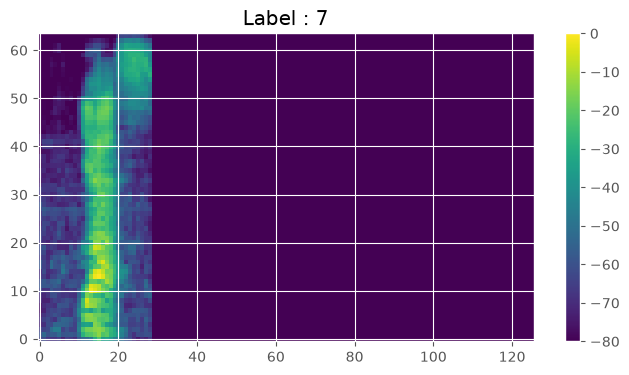

In [44]:
plt.figure(figsize=(8,4))

plt.imshow(

    spectrograms[0][0],

    aspect="auto",

    origin="lower"

)

plt.title(f"Label : {labels[0].item()}")

plt.colorbar()

plt.show()

In [45]:
print("Train Samples :", len(train_dataset))

print("Validation Samples :", len(val_dataset))

print("Test Samples :", len(test_dataset))

Train Samples : 5599
Validation Samples : 1201
Test Samples : 1200


Step-4

In [46]:
import torch
import torch.nn as nn

In [47]:
class AudioCNN(nn.Module):

    def __init__(self, num_classes):

        super(AudioCNN, self).__init__()

        # First Convolution Block
        self.conv1 = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        # Second Convolution Block
        self.conv2 = nn.Sequential(

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        # Third Convolution Block
        self.conv3 = nn.Sequential(

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)
        )

        # Adaptive Pooling
        self.pool = nn.AdaptiveAvgPool2d((4,4))

        # Fully Connected Layers
        self.fc = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 4 * 4, 128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        x = self.conv1(x)

        x = self.conv2(x)

        x = self.conv3(x)

        x = self.pool(x)

        x = self.fc(x)

        return x

In [48]:
num_classes = len(classes)

model = AudioCNN(num_classes)

print(model)

AudioCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=8, bias=True)
  )
)


In [49]:
spectrograms, labels = next(iter(train_loader))

print(spectrograms.shape)

torch.Size([32, 1, 64, 126])


In [50]:
outputs = model(spectrograms)

print(outputs.shape)

torch.Size([32, 8])


In [51]:
predictions = torch.argmax(outputs, dim=1)

print("Predicted Labels:")
print(predictions)

Predicted Labels:
tensor([0, 0, 3, 0, 0, 0, 0, 5, 5, 0, 6, 5, 5, 0, 5, 3, 0, 0, 6, 0, 6, 0, 5, 0,
        5, 6, 3, 6, 5, 6, 6, 0])


In [52]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total Parameters:", total_params)
print("Trainable Parameters:", trainable_params)

Total Parameters: 155528
Trainable Parameters: 155528


Step-5

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cpu


In [55]:
model = AudioCNN(num_classes=len(classes))

model = model.to(device)

In [56]:
criterion = nn.CrossEntropyLoss()

In [57]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [58]:
EPOCHS = 15

In [59]:
train_losses = []

train_accuracies = []

val_accuracies = []

In [ ]:
for epoch in range(EPOCHS):

    #########################################
    # TRAINING
    #########################################

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for spectrograms, labels in train_loader:

        spectrograms = spectrograms.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(spectrograms)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_accuracy = 100 * correct / total

    #########################################
    # VALIDATION
    #########################################

    model.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for spectrograms, labels in val_loader:

            spectrograms = spectrograms.to(device)

            labels = labels.to(device)

            outputs = model(spectrograms)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total

    #########################################

    train_losses.append(train_loss)

    train_accuracies.append(train_accuracy)

    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss={train_loss:.4f} | "
        f"Train Acc={train_accuracy:.2f}% | "
        f"Val Acc={val_accuracy:.2f}%"
    )

In [61]:
print(len(train_dataset))
print(len(train_loader))

5599
175


In [62]:
import time

start = time.time()

x, y = train_dataset[0]

print("Shape:", x.shape)
print("Label:", y)

end = time.time()

print("Time Taken:", end - start)

Shape: torch.Size([1, 64, 126])
Label: tensor(5)
Time Taken: 0.043183326721191406


In [63]:
for i, (x, y) in enumerate(train_loader):
    print(i)
    print(x.shape)
    print(y.shape)
    break

0
torch.Size([32, 1, 64, 126])
torch.Size([32])


In [64]:
spectrograms, labels = next(iter(train_loader))

spectrograms = spectrograms.to(device)

outputs = model(spectrograms)

print(outputs.shape)

torch.Size([32, 8])


In [65]:
labels = labels.to(device)

loss = criterion(outputs, labels)

print(loss)

tensor(0.3391, grad_fn=<NllLossBackward0>)


In [66]:
optimizer.zero_grad()

loss.backward()

optimizer.step()

print("One training step completed!")

One training step completed!


In [68]:
for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for batch_idx, (spectrograms, labels) in enumerate(train_loader):

        if batch_idx % 20 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)}")

        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(spectrograms)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    # Continue with the validation code exactly as before...

Epoch 1 | Batch 0/175
Epoch 1 | Batch 20/175
Epoch 1 | Batch 40/175
Epoch 1 | Batch 60/175
Epoch 1 | Batch 80/175
Epoch 1 | Batch 100/175
Epoch 1 | Batch 120/175
Epoch 1 | Batch 140/175
Epoch 1 | Batch 160/175
Epoch 2 | Batch 0/175
Epoch 2 | Batch 20/175
Epoch 2 | Batch 40/175
Epoch 2 | Batch 60/175
Epoch 2 | Batch 80/175
Epoch 2 | Batch 100/175
Epoch 2 | Batch 120/175
Epoch 2 | Batch 140/175
Epoch 2 | Batch 160/175
Epoch 3 | Batch 0/175
Epoch 3 | Batch 20/175
Epoch 3 | Batch 40/175
Epoch 3 | Batch 60/175
Epoch 3 | Batch 80/175
Epoch 3 | Batch 100/175
Epoch 3 | Batch 120/175
Epoch 3 | Batch 140/175
Epoch 3 | Batch 160/175
Epoch 4 | Batch 0/175
Epoch 4 | Batch 20/175
Epoch 4 | Batch 40/175
Epoch 4 | Batch 60/175
Epoch 4 | Batch 80/175
Epoch 4 | Batch 100/175
Epoch 4 | Batch 120/175
Epoch 4 | Batch 140/175
Epoch 4 | Batch 160/175
Epoch 5 | Batch 0/175
Epoch 5 | Batch 20/175
Epoch 5 | Batch 40/175
Epoch 5 | Batch 60/175
Epoch 5 | Batch 80/175
Epoch 5 | Batch 100/175
Epoch 5 | Batch 120/17

In [69]:
#########################################
# Calculate Training Accuracy
#########################################

train_loss = running_loss / len(train_loader)
train_accuracy = 100 * correct / total

#########################################
# Validation
#########################################

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for spectrograms, labels in val_loader:

        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        outputs = model(spectrograms)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_accuracy = 100 * correct / total

print("="*50)
print(f"Training Loss     : {train_loss:.4f}")
print(f"Training Accuracy : {train_accuracy:.2f}%")
print(f"Validation Accuracy : {val_accuracy:.2f}%")
print("="*50)

Training Loss     : 0.1148
Training Accuracy : 95.78%
Validation Accuracy : 90.51%


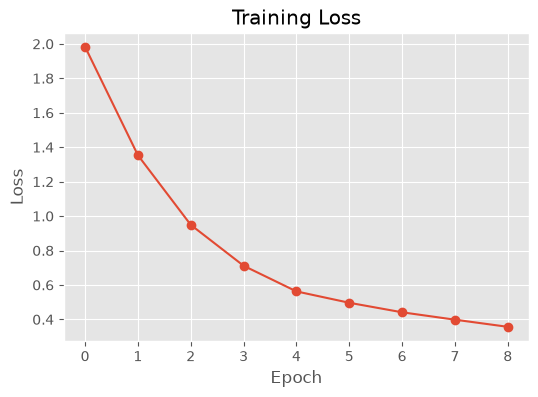

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

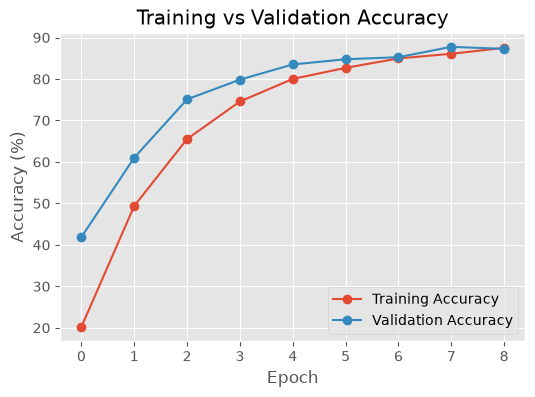

In [71]:
plt.figure(figsize=(6,4))

plt.plot(train_accuracies, label="Training Accuracy", marker='o')
plt.plot(val_accuracies, label="Validation Accuracy", marker='o')

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

Step-6

In [74]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for spectrograms, labels in test_loader:

        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        outputs = model(spectrograms)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions, average="macro")
recall = recall_score(all_labels, all_predictions, average="macro")
f1 = f1_score(all_labels, all_predictions, average="macro")

print("="*50)
print(f"Test Accuracy   : {accuracy*100:.2f}%")
print(f"Macro Precision : {precision:.4f}")
print(f"Macro Recall    : {recall:.4f}")
print(f"Macro F1-score  : {f1:.4f}")
print("="*50)

Test Accuracy   : 90.92%
Macro Precision : 0.9111
Macro Recall    : 0.9092
Macro F1-score  : 0.9087


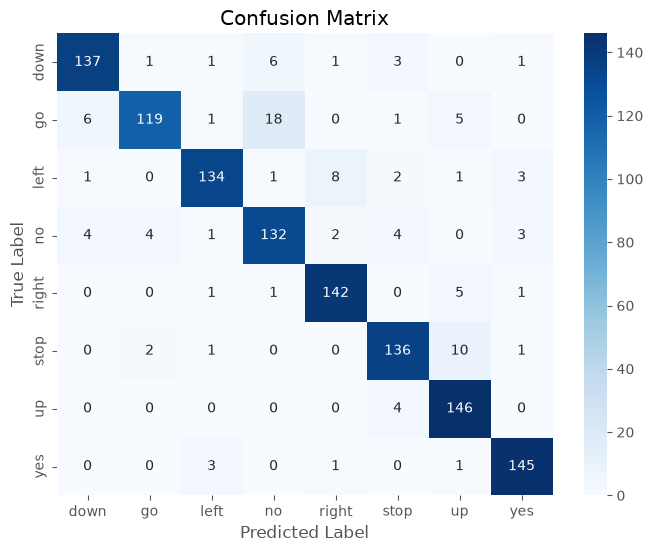

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [76]:
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=classes
    )
)

              precision    recall  f1-score   support

        down       0.93      0.91      0.92       150
          go       0.94      0.79      0.86       150
        left       0.94      0.89      0.92       150
          no       0.84      0.88      0.86       150
       right       0.92      0.95      0.93       150
        stop       0.91      0.91      0.91       150
          up       0.87      0.97      0.92       150
         yes       0.94      0.97      0.95       150

    accuracy                           0.91      1200
   macro avg       0.91      0.91      0.91      1200
weighted avg       0.91      0.91      0.91      1200



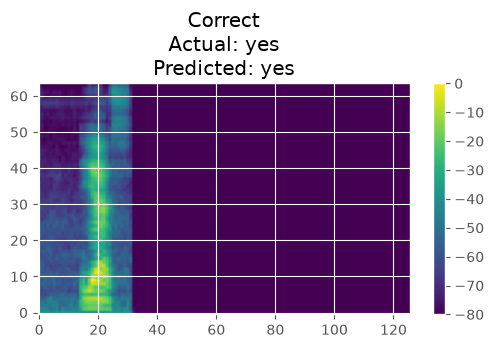

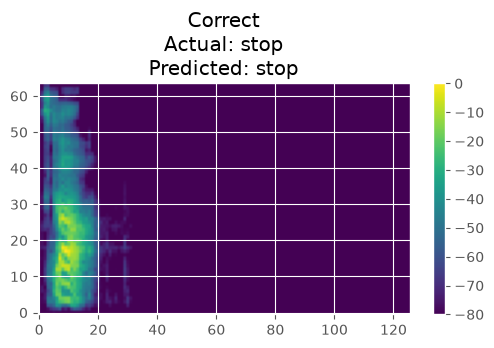

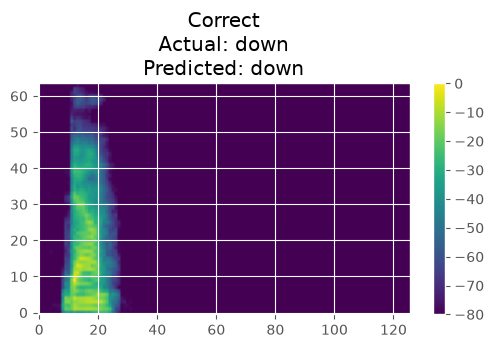

In [77]:
import matplotlib.pyplot as plt

model.eval()

shown = 0

with torch.no_grad():

    for spectrograms, labels in test_loader:

        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        outputs = model(spectrograms)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):

            if predicted[i] == labels[i]:

                plt.figure(figsize=(6,3))

                plt.imshow(
                    spectrograms[i][0].cpu(),
                    origin="lower",
                    aspect="auto"
                )

                plt.title(
                    f"Correct\nActual: {classes[labels[i]]}\nPredicted: {classes[predicted[i]]}"
                )

                plt.colorbar()

                plt.show()

                shown += 1

                if shown == 3:
                    break

        if shown == 3:
            break

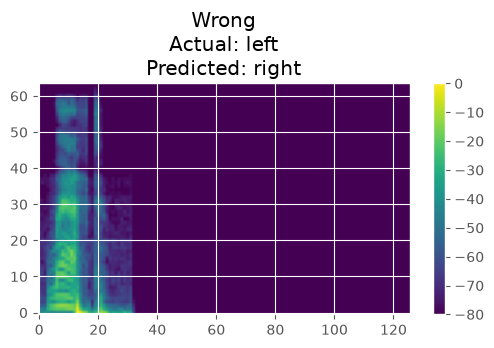

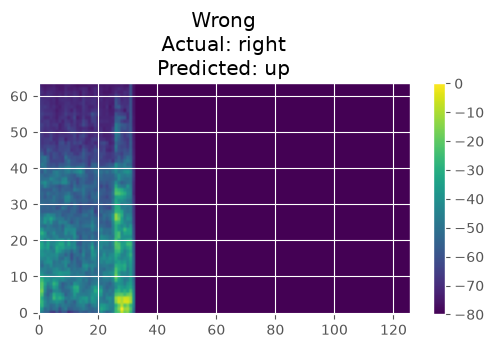

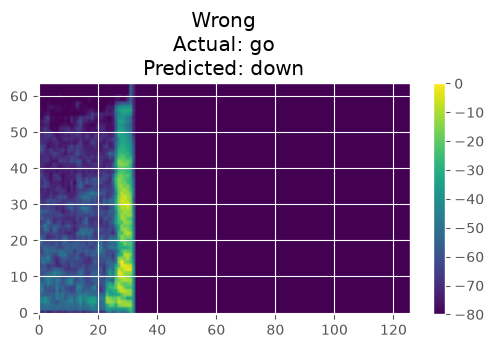

In [78]:
shown = 0

with torch.no_grad():

    for spectrograms, labels in test_loader:

        spectrograms = spectrograms.to(device)
        labels = labels.to(device)

        outputs = model(spectrograms)

        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):

            if predicted[i] != labels[i]:

                plt.figure(figsize=(6,3))

                plt.imshow(
                    spectrograms[i][0].cpu(),
                    origin="lower",
                    aspect="auto"
                )

                plt.title(
                    f"Wrong\nActual: {classes[labels[i]]}\nPredicted: {classes[predicted[i]]}"
                )

                plt.colorbar()

                plt.show()

                shown += 1

                if shown == 3:
                    break

        if shown == 3:
            break

In [79]:
import random
import torch

class SpecAugment:
    def __init__(self,
                 freq_mask_param=15,
                 time_mask_param=35,
                 num_freq_masks=2,
                 num_time_masks=2):

        self.F = freq_mask_param
        self.T = time_mask_param
        self.num_freq_masks = num_freq_masks
        self.num_time_masks = num_time_masks

    ##################################################
    # Frequency Mask
    ##################################################
    def freq_mask(self, spec):

        _, n_mels, n_frames = spec.shape

        f = random.randint(0, self.F)

        if f == 0:
            return spec

        f0 = random.randint(0, max(0, n_mels - f))

        spec[:, f0:f0+f, :] = 0

        return spec

    ##################################################
    # Time Mask
    ##################################################
    def time_mask(self, spec):

        _, n_mels, n_frames = spec.shape

        t = random.randint(0, self.T)

        if t == 0:
            return spec

        t0 = random.randint(0, max(0, n_frames - t))

        spec[:, :, t0:t0+t] = 0

        return spec

    ##################################################
    # Apply SpecAugment
    ##################################################
    def __call__(self, spec):

        spec = spec.clone()

        for _ in range(self.num_freq_masks):
            spec = self.freq_mask(spec)

        for _ in range(self.num_time_masks):
            spec = self.time_mask(spec)

        return spec

In [80]:
augment = SpecAugment()

sample_spec, label = train_dataset[0]

print(sample_spec.shape)
print(label)

torch.Size([1, 64, 126])
tensor(5)


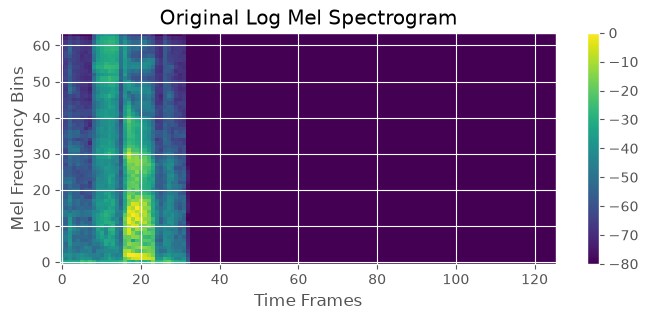

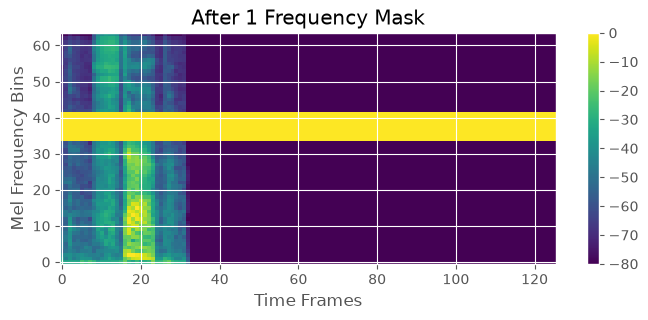

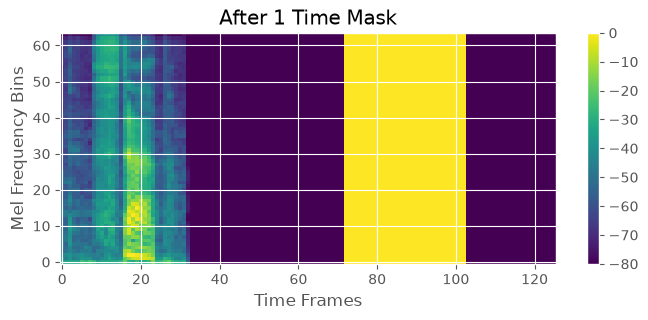

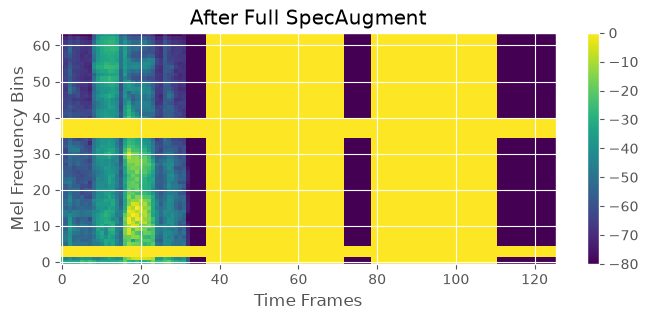

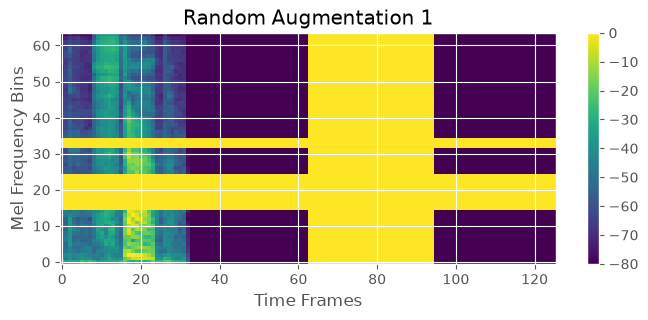

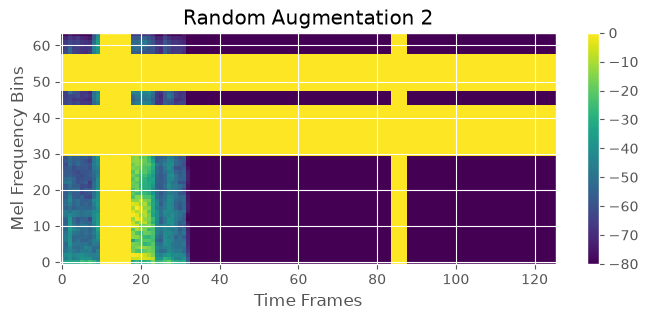

In [81]:
############################################################
# STEP 8 : Visualize SpecAugment
############################################################

import matplotlib.pyplot as plt
import torch

# Get one spectrogram from training dataset
original_spec, label = train_dataset[0]

############################################################
# Plot helper
############################################################

def plot_spec(spec, title):

    plt.figure(figsize=(8,3))

    plt.imshow(
        spec.squeeze(0).cpu(),
        aspect="auto",
        origin="lower",
        cmap="viridis"
    )

    plt.title(title)
    plt.xlabel("Time Frames")
    plt.ylabel("Mel Frequency Bins")

    plt.colorbar()

    plt.show()


############################################################
# Plot 1 : Original
############################################################

plot_spec(original_spec, "Original Log Mel Spectrogram")


############################################################
# Plot 2 : One Frequency Mask
############################################################

freq_aug = SpecAugment(
    freq_mask_param=15,
    time_mask_param=0,
    num_freq_masks=1,
    num_time_masks=0
)

freq_spec = freq_aug(original_spec.clone())

plot_spec(freq_spec, "After 1 Frequency Mask")


############################################################
# Plot 3 : One Time Mask
############################################################

time_aug = SpecAugment(
    freq_mask_param=0,
    time_mask_param=35,
    num_freq_masks=0,
    num_time_masks=1
)

time_spec = time_aug(original_spec.clone())

plot_spec(time_spec, "After 1 Time Mask")


############################################################
# Plot 4 : Full SpecAugment
############################################################

full_aug = SpecAugment()

full_spec = full_aug(original_spec.clone())

plot_spec(full_spec, "After Full SpecAugment")


############################################################
# Plot 5 : Random Augmentation #1
############################################################

random_aug1 = SpecAugment()

spec1 = random_aug1(original_spec.clone())

plot_spec(spec1, "Random Augmentation 1")


############################################################
# Plot 6 : Random Augmentation #2
############################################################

random_aug2 = SpecAugment()

spec2 = random_aug2(original_spec.clone())

plot_spec(spec2, "Random Augmentation 2")

Epoch 1/10 | Loss=2.0935 | Train Acc=11.72% | Val Acc=12.49%
Epoch 2/10 | Loss=2.0807 | Train Acc=12.50% | Val Acc=12.49%
Epoch 3/10 | Loss=2.0799 | Train Acc=12.36% | Val Acc=12.49%
Epoch 4/10 | Loss=2.0802 | Train Acc=12.11% | Val Acc=12.49%
Epoch 5/10 | Loss=2.0799 | Train Acc=11.89% | Val Acc=12.49%
Epoch 6/10 | Loss=2.0801 | Train Acc=12.38% | Val Acc=12.49%
Epoch 7/10 | Loss=2.0807 | Train Acc=11.56% | Val Acc=12.49%
Epoch 8/10 | Loss=2.0800 | Train Acc=11.34% | Val Acc=12.49%
Epoch 9/10 | Loss=2.0799 | Train Acc=12.25% | Val Acc=12.49%
Epoch 10/10 | Loss=2.0800 | Train Acc=12.54% | Val Acc=12.49%

Training with SpecAugment Done!


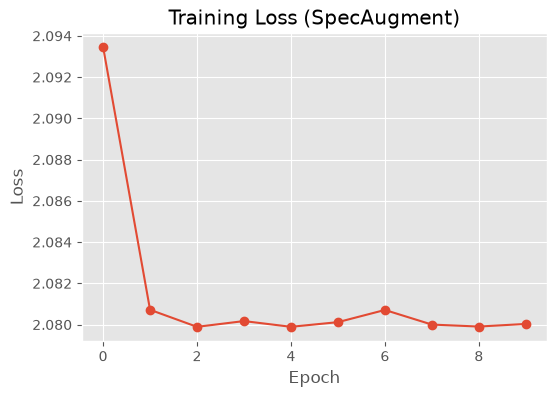

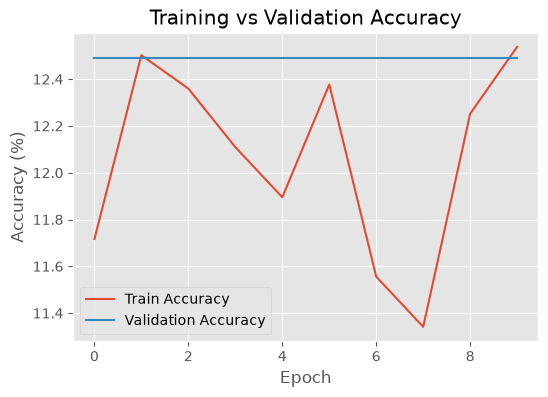

In [82]:
############################################
# STEP 9 - TRAINING WITH SPECAUGMENT
############################################

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

############################################
# Create NEW datasets
############################################

train_dataset_aug = AudioDataset(
    train_files,
    train_labels,
    preprocessor,
    augment=SpecAugment()      # <-- Apply augmentation only here
)

val_dataset_aug = AudioDataset(
    val_files,
    val_labels,
    preprocessor,
    augment=None
)

test_dataset_aug = AudioDataset(
    test_files,
    test_labels,
    preprocessor,
    augment=None
)

############################################
# DataLoaders
############################################

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=32,
    shuffle=True
)

val_loader_aug = DataLoader(
    val_dataset_aug,
    batch_size=32,
    shuffle=False
)

test_loader_aug = DataLoader(
    test_dataset_aug,
    batch_size=32,
    shuffle=False
)

############################################
# Create NEW model
############################################

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_aug = AudioCNN(num_classes=len(classes)).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_aug.parameters(),
    lr=0.001
)

EPOCHS = 10

############################################
# Store history
############################################

train_losses_aug = []

train_accuracies_aug = []

val_accuracies_aug = []

############################################
# Training Loop
############################################

for epoch in range(EPOCHS):

    ###########################
    # TRAIN
    ###########################

    model_aug.train()

    running_loss = 0

    correct = 0

    total = 0

    for spectrograms, labels in train_loader_aug:

        spectrograms = spectrograms.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_aug(spectrograms)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted==labels).sum().item()

    train_loss = running_loss / len(train_loader_aug)

    train_accuracy = 100 * correct / total

    ###########################
    # VALIDATION
    ###########################

    model_aug.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for spectrograms, labels in val_loader_aug:

            spectrograms = spectrograms.to(device)

            labels = labels.to(device)

            outputs = model_aug(spectrograms)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()

    val_accuracy = 100 * correct / total

    ###########################

    train_losses_aug.append(train_loss)

    train_accuracies_aug.append(train_accuracy)

    val_accuracies_aug.append(val_accuracy)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss={train_loss:.4f} | "
        f"Train Acc={train_accuracy:.2f}% | "
        f"Val Acc={val_accuracy:.2f}%"
    )

############################################
# Training Completed
############################################

print("\n===============================")
print("Training with SpecAugment Done!")
print("===============================")

############################################
# Plot Loss
############################################

plt.figure(figsize=(6,4))

plt.plot(train_losses_aug, marker="o")

plt.title("Training Loss (SpecAugment)")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

############################################
# Plot Accuracy
############################################

plt.figure(figsize=(6,4))

plt.plot(train_accuracies_aug,label="Train Accuracy")

plt.plot(val_accuracies_aug,label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid(True)

plt.show()

Step-10

D:\Anaconda\envs\opencv-env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\envs\opencv-env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\envs\opencv-env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\Anaconda\envs\op

Test Accuracy : 12.50%
Precision     : 0.0156
Recall        : 0.1250
F1 Score      : 0.0278
              precision    recall  f1-score   support

        down       0.00      0.00      0.00       150
          go       0.00      0.00      0.00       150
        left       0.00      0.00      0.00       150
          no       0.12      1.00      0.22       150
       right       0.00      0.00      0.00       150
        stop       0.00      0.00      0.00       150
          up       0.00      0.00      0.00       150
         yes       0.00      0.00      0.00       150

    accuracy                           0.12      1200
   macro avg       0.02      0.12      0.03      1200
weighted avg       0.02      0.12      0.03      1200



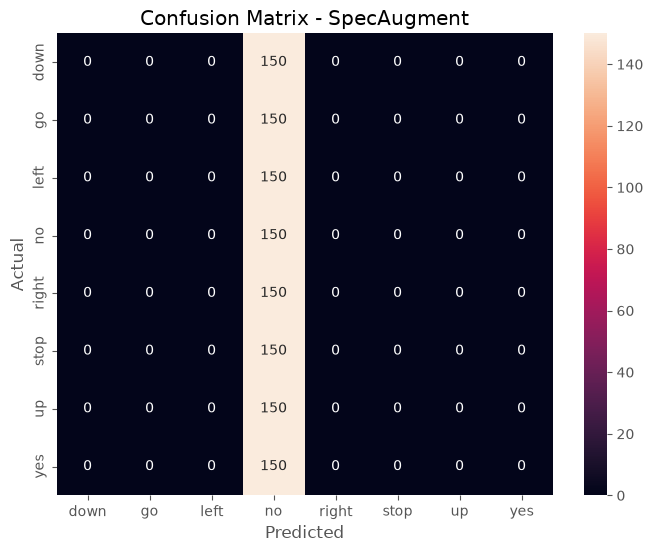

===== Correct Predictions =====


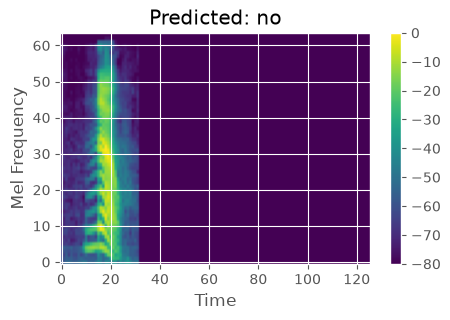

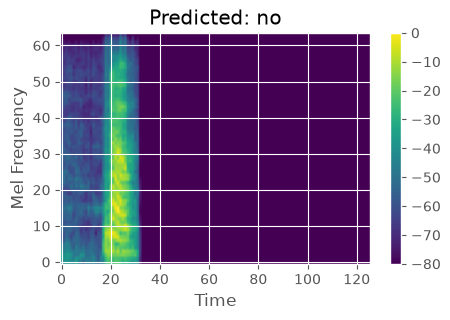

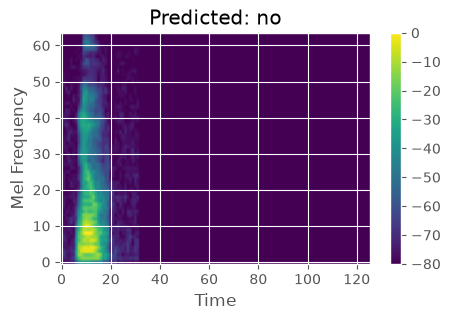

===== Wrong Predictions =====


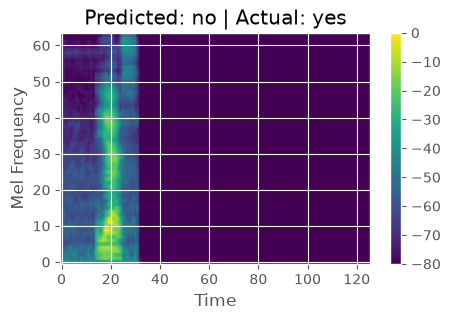

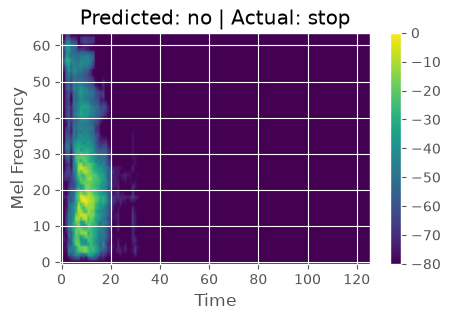

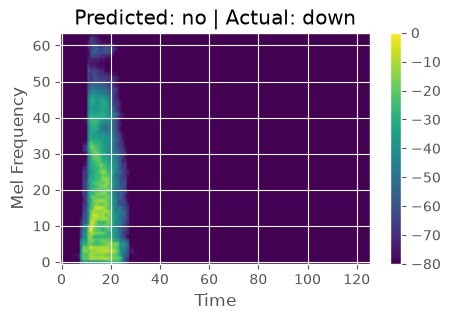

In [83]:
############################################
# STEP 10 - EVALUATION WITH SPECAUGMENT
############################################

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns


############################################
# Put model in evaluation mode
############################################

model_aug.eval()


all_predictions = []
all_labels = []

correct_examples = []
wrong_examples = []


############################################
# Testing
############################################

with torch.no_grad():

    for spectrograms, labels in test_loader_aug:

        spectrograms = spectrograms.to(device)

        labels = labels.to(device)


        outputs = model_aug(spectrograms)


        _, predicted = torch.max(outputs,1)


        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


        ################################
        # Store examples
        ################################

        for i in range(len(labels)):

            spec = spectrograms[i].cpu()

            actual = labels[i].item()

            pred = predicted[i].item()


            if pred == actual:

                if len(correct_examples) < 3:

                    correct_examples.append(
                        (spec, pred)
                    )


            else:

                if len(wrong_examples) < 3:

                    wrong_examples.append(
                        (spec, pred, actual)
                    )


############################################
# Metrics
############################################

accuracy = accuracy_score(
    all_labels,
    all_predictions
)


precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)


recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)


f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)



print("===============================")

print(
    f"Test Accuracy : {accuracy*100:.2f}%"
)

print(
    f"Precision     : {precision:.4f}"
)

print(
    f"Recall        : {recall:.4f}"
)

print(
    f"F1 Score      : {f1:.4f}"
)

print("===============================")



############################################
# Classification Report
############################################

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=classes
    )
)


############################################
# Confusion Matrix
############################################

cm = confusion_matrix(
    all_labels,
    all_predictions
)


plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Confusion Matrix - SpecAugment"
)

plt.show()



############################################
# Correct Predictions
############################################

print("===== Correct Predictions =====")


for spec,pred in correct_examples:

    plt.figure(figsize=(5,3))

    plt.imshow(
        spec.squeeze(),
        aspect="auto",
        origin="lower"
    )

    plt.title(
        f"Predicted: {classes[pred]}"
    )

    plt.xlabel("Time")

    plt.ylabel("Mel Frequency")

    plt.colorbar()

    plt.show()



############################################
# Wrong Predictions
############################################


print("===== Wrong Predictions =====")


for spec,pred,actual in wrong_examples:

    plt.figure(figsize=(5,3))


    plt.imshow(
        spec.squeeze(),
        aspect="auto",
        origin="lower"
    )


    plt.title(
        f"Predicted: {classes[pred]} | Actual: {classes[actual]}"
    )


    plt.xlabel("Time")

    plt.ylabel("Mel Frequency")

    plt.colorbar()

    plt.show()